# ACLR Individual EDA

Name: Oliver Meek

In [135]:
#import all the packages we need
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [136]:
#loading in the data and taking a first look
aclr = pd.read_csv('/workspaces/DS-3021/data/aclr data(in).csv')
aclr.head()

,record_id,redcap_event_name,redcap_repeat_instrument,sex_dashboard,graft_dashboard2,med_meniscus,lat_meniscus,lat_stab,physis,visit_sex,...,lsi_flex_mvic_60,acl_ext_isok_60,con_ext_isok_60,lsi_ext_isok_60,acl_flex_isok_60,con_flex_isok_60,lsi_flex_isok_60,strength_testing_complete,rts,rts_tss
0,1,baseline_arm_1,NaN,Male,Other,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,visit_1_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,...,NaN,2.57,2.92,87.86,1.50,1.45,103.32,2.0,NaN,NaN
2,1,long_term_outcomes_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,70.0
3,2,baseline_arm_1,NaN,Female,HS autograft,1.0,3.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,visit_1_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Female,...,NaN,0.97,2.16,45.00,0.88,1.20,72.98,2.0,NaN,NaN


The first thing that jumps out to me is that there are a lot of missing values, but given that this data is longitudinal and each patient (indicated by 'record_id') has multiple entires, it makes sense that some values would not be repeated and left blank from row to row.

### Understanding the overall data and assessing missing data

In [137]:
aclr.shape
#this tells us that there are 63 variables and 11,150 observations/rows

(11150, 63)

In [138]:
num_patients = aclr['record_id'].nunique()
print(num_patients)

4739


This tells us that there are 4,739 patients in the dataset. Assuming variables that remain constant for a patient are only reported once, we can expect around 4,739 non-null values in those rows

In [139]:
#let's see how many missing values there are in each variable
aclr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11150 entries, 0 to 11149
Data columns (total 63 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   record_id                  11150 non-null  int64  
 1   redcap_event_name          11150 non-null  object 
 2   redcap_repeat_instrument   0 non-null      float64
 3   sex_dashboard              4737 non-null   object 
 4   graft_dashboard2           4737 non-null   object 
 5   med_meniscus               4121 non-null   float64
 6   lat_meniscus               4121 non-null   float64
 7   lat_stab                   3662 non-null   float64
 8   physis                     936 non-null    float64
 9   visit_sex                  5234 non-null   object 
 10  visit_graft                5234 non-null   object 
 11  age                        5126 non-null   float64
 12  age_group                  5126 non-null   float64
 13  age_group_dashboard        4724 non-null   flo

One thing to note is that I'm seeing a mix of categorical and continuous variables.

I'm seeing around 4,739 non-null values for variables like sex and graft type, which follows if there are that many patients. I also see some variables with 0 non-null variables, so I'm going to assume those are not relevant and drop them. 

In [140]:
aclr = aclr.drop(['tss_tegner', 'redcap_repeat_instrument'], axis = 1)

As mentioned, much of the values that appear missing are actually informed by the record_id. I'm going to use the number of patients as a reference point to determine how many truly missing values there are in each column

In [ ]:
non_nulls = aclr.notnull().sum()
non_nulls_ref = non_nulls - 4739
non_nulls_ref = non_nulls_ref.sort_values()
non_nulls_ref.head(20)
#a number greater than zero means that at least some patients have multiple entries for that variable ati different times
#a number less than zero means that there are missing values in that variable
#I printed out the 20 variables with the most missing values


pedi_fabs          -4702
rts_tss            -4068
rts                -4053
lsi_ext_mvic_90    -4041
acl_ext_mvic_90    -4041
con_ext_mvic_90    -4039
marx               -3828
physis             -3803
con_flex_mvic_60   -3731
lsi_flex_mvic_60   -3730
acl_flex_mvic_60   -3728
tsk                -3728
acl_ext_mvic_60    -3720
lsi_ext_mvic_60    -3720
con_ext_mvic_60    -3720
ch_lsi             -3389
con_ch             -3383
acl_ch             -3329
acl_th             -3188
th_lsi             -3187
dtype: int64

Despite accounting for the record_id, there are still a lot of missing values in this dataset. This is likely because different doctors performed different tests on different patients. I will need to consider many different recovery metrics if I really want to show the full data

I'm also interested to see if there are any differences between columns like 'sex_dashboard' and 'visit_sex'

In [ ]:
col_list = ['record_id', 'sex_dashboard', 'visit_sex', 'graft_dashboard2', 'visit_graft', 'tss', 'tss_dashboard']
aclr[col_list]

'dashboard' and 'visit' values appear to be the same for each patient, and just depend on whether the data was collected at the first visut or at followups.

To make things simpler, I merged these kinds of columns

In [ ]:
aclr['sex'] = aclr['sex_dashboard'].fillna(aclr['visit_sex'])
aclr['sex'] = aclr['sex'].ffill()
aclr['graft'] = aclr['graft_dashboard2'].fillna(aclr['visit_graft'])
aclr['graft'] = aclr['graft'].ffill()

### Identifying important variables and understanding how the data is nested

To start better understanding the dataset, I reviewed the information on acldashboard.com and noted down the variables that seemed most important, keeping in mind what I learned from making my infographic and reading the ACLR study.
* 'record_id': unique identifier for each patient (I conceptualize the data ad being "grouped" by this variable)
* 'redcap_event_name': indicates what visit the data was collected at (baseline, first followup, etc)
* 'sex_dashboard': the sex of the patient
* 'graft_dashboard2': the type of graft used in the surgery
* 'height_m', 'weight_kg', etc: various demographics of the patient
* 'tss' and 'tss_dashboard' are continuous and categorical versions of the time since surgery data was recorded.

a lot of what's of most interest to me is the metrics for measuring knee strength and recovery. Many of these are repeated measure. These include:
* 'ikdc' and 'pedi_ikdc': the International Knee Documentation Committee (IKDC) score (pedi if patient is under 18), which is a measure of knee function and symptoms. 100 indicated perfect function, 0 indicates no function
* 'acl_rsi': indicates psychological readiness to return to sport after ACL injury. 100 indicates full confidence, 0 indicates no confidence
* 'tsk': Tampa Scale of Kinesiophobia, which measures fear of movement and reinjury, similar to ACL-RSI
* 'ext' in a variable indicated a measure of the limb's extension torque
* 'flex' in a variable indicated a measure of the limb's flexion torque
* 'mvic' and 'isok' in a variable refers to the kind of muscle contraction being measuured
* 'acl' in a variable indicates that the knee being measured is the ACL-repaired knee
* 'con' in a variable indicates that the knee being measured is the contralateral knee (the knee not being repaired)
* 'lsi' in a variable indicates that the value is a limb symmetry index, which is a measure of how similar the two knees are in terms of strength and function. 
* 'sh', 'th', and 'ch' are all different function tests for the knees involving hopping
* 'koos' refers to the Knee Injury and Osteoarthritis Outcome Score, and there are 5 subcategories of this each with their own variable
* 'marx' and 'tegner' are also more holistic activity level measures



From making my infographic, I know that some key variables impacting recovery are age, sex, and graft type. Let's check out the distribution of these variables in our dataset. 

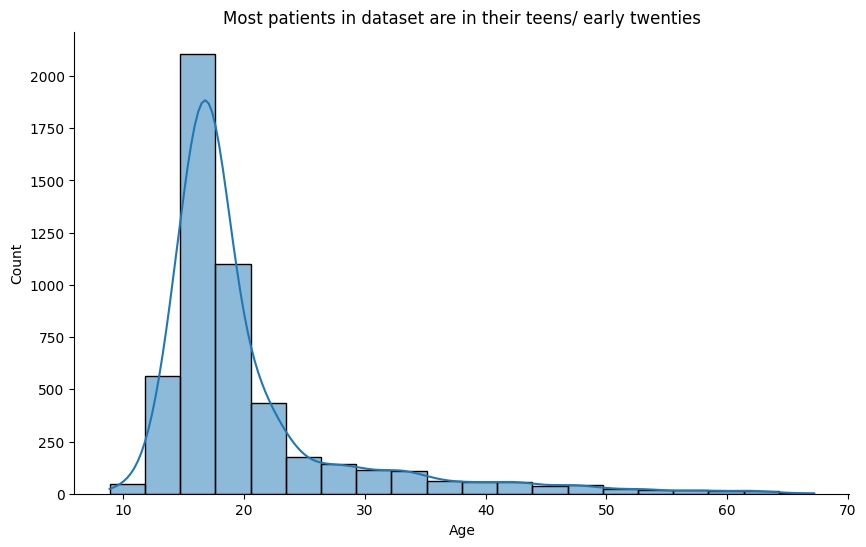

In [143]:
#age histogram
plt.figure(figsize=(10, 6))
sns.histplot(aclr['age'], bins=20, kde=True)
plt.title('Most patients in dataset are in their teens/ early twenties')
plt.xlabel('Age')
sns.despine()

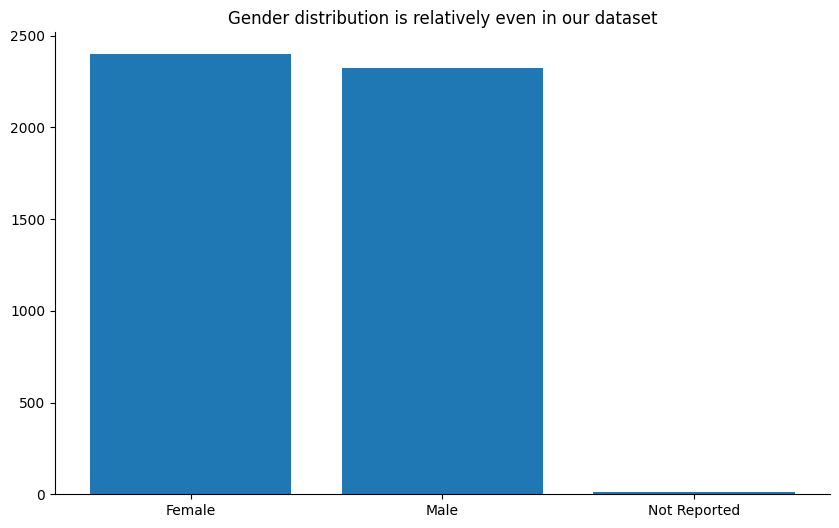

In [144]:
#bar graph for sex
sex_counts = aclr['sex_dashboard'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(sex_counts.index, sex_counts.values)
plt.title('Gender distribution is relatively even in our dataset')
sns.despine()

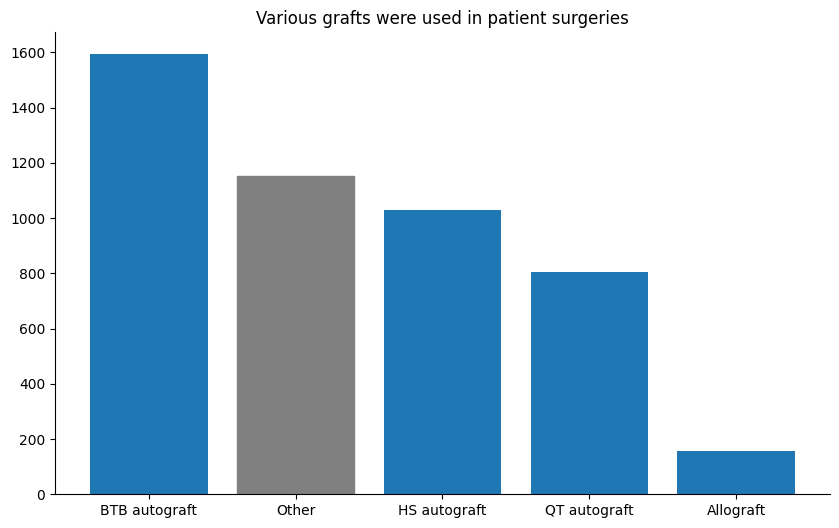

In [145]:
#bar graph for graft types
graft_counts = aclr['graft_dashboard2'].value_counts()
plt.figure(figsize=(10, 6))
bars = plt.bar(graft_counts.index, graft_counts.values)

for bar, label in zip(bars, graft_counts.index):
    if label == 'Other':
        bar.set_color('grey')

plt.title('Various grafts were used in patient surgeries')
sns.despine()

Lets see if there's any difference in how the graft type effects IKDC

In [ ]:
tss_df = aclr.groupby('graft')['ikdc'].mean()
tss_df = tss_df.reset_index()
tss_df.sort_values('ikdc', ascending=False, inplace=True)
tss_df
#looks like HS allograft performs the best on average, but this doesn't account for time since surgery

,graft,ikdc
2,HS autograft,80.612798
0,Allograft,78.982929
1,BTB autograft,77.618440
4,QT autograft,77.135903
3,Other,76.260753


It's likely that many of the knee strength and recovery variables are collinear. To check this out, I made some pairplots and heatmaps. I focused on evaluations using the limb symmetry index, because that accounts for differences in individual patients

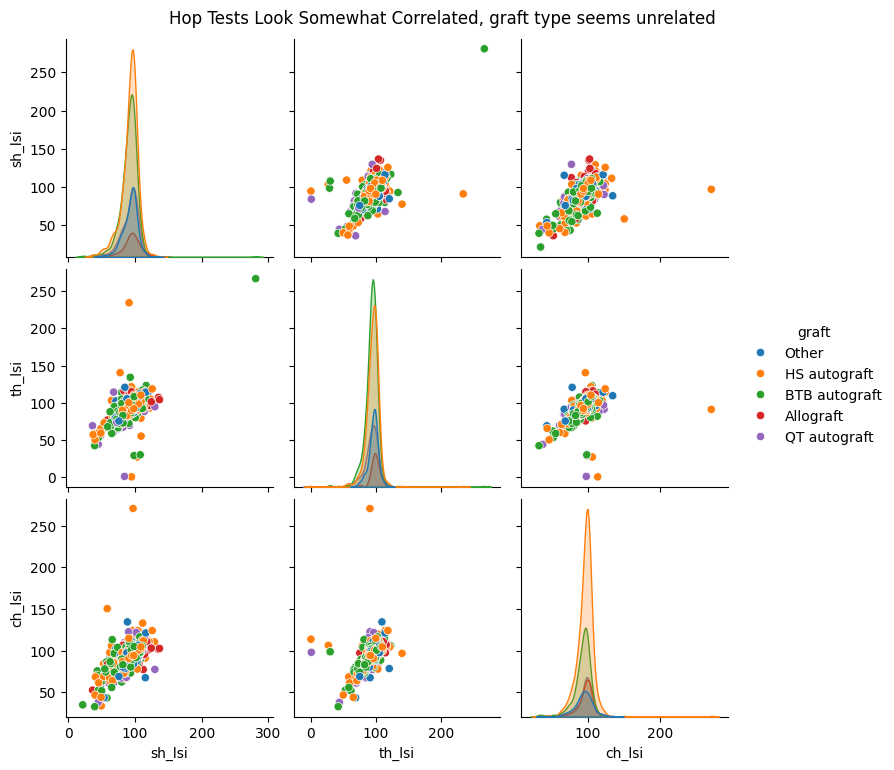

In [171]:
# Create the pairplot
pairplot = sns.pairplot(aclr, vars=['sh_lsi', 'th_lsi', 'ch_lsi'], hue='graft')
pairplot.fig.suptitle('Hop Tests Look Somewhat Correlated, graft type seems unrelated', y=1.02) 
plt.show()

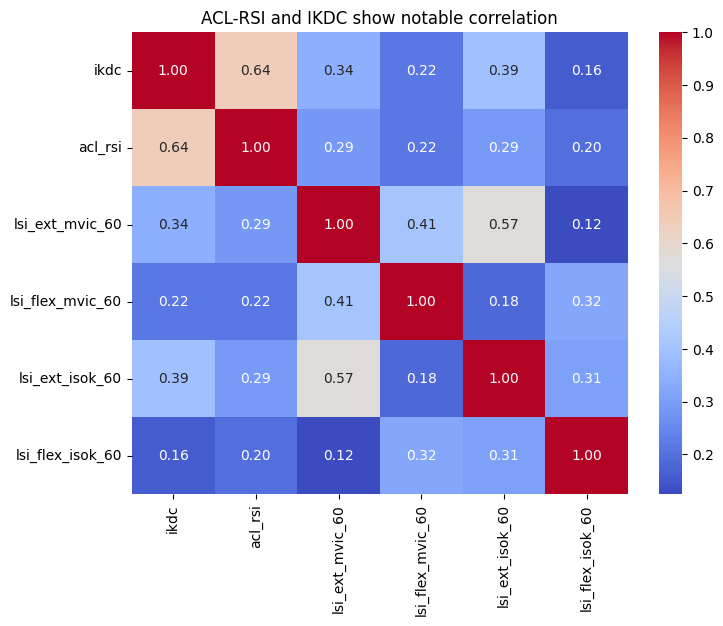

In [167]:
interesting_columns = ['ikdc', 'acl_rsi', 'lsi_ext_mvic_60', 'lsi_flex_mvic_60', 
                       'lsi_ext_isok_60', 'lsi_flex_isok_60']

corrmat = aclr[interesting_columns].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corrmat, annot = True, cmap='coolwarm', fmt=".2f")
plt.title("ACL-RSI and IKDC show notable correlation")
plt.show()

Despite some correlations, a lot of knee strength measurements are quite unique and don't have a strong relationship with each other. This means we should consider all of as distinct recovery measures. Ones like IKDC and ACL_RSI, however, are more holistic by definition.

Text(0.5, 1.0, 'Taking a closer look ACL-RSI and IKDC')

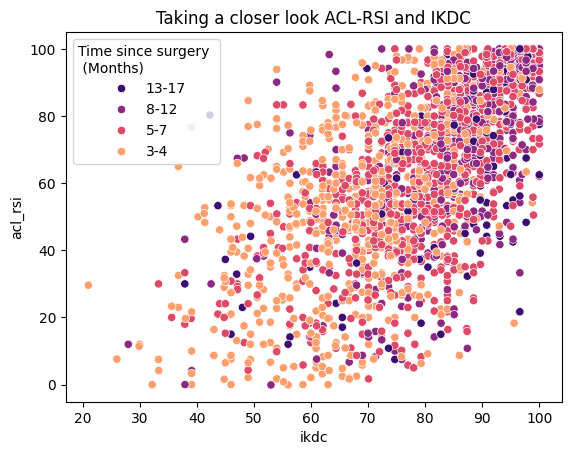

In [196]:
aclr_filtered = aclr[(aclr['tss_dashboard'] != 'Not Reported') & (aclr['tss_dashboard'] != 'Preoperative')]
sns.scatterplot(data=aclr_filtered, x='ikdc', y='acl_rsi', hue='tss_dashboard', palette="magma",
                hue_order=['13 to 24 months', '8 to 12 months', '5 to 7 months', '3 to 4 months'])

# Get the current legend handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Define the desired order of labels
desired_order = ['13 to 24 months', '8 to 12 months', '5 to 7 months', '3 to 4 months']

# Reorder the handles and labels based on the desired order
ordered_handles = [handles[labels.index(label)] for label in desired_order]
ordered_labels = [label for label in desired_order]

# Update the legend with the reordered handles and labels
plt.legend(handles=ordered_handles, title='Time since surgery \n (Months)',
           labels=['13-17', '8-12','5-7', '3-4'])

plt.title('Taking a closer look ACL-RSI and IKDC')

I also wanted to get some summary statistics for the recovery metrics:

In [201]:
interesting_columns = ['sh_lsi', 'th_lsi', 'ch_lsi', 'acl_rsi', 'lsi_ext_mvic_60',
                       'lsi_flex_mvic_60', 'lsi_ext_isok_60', 'lsi_flex_isok_60']
aclr[interesting_columns].describe()

/workspaces/DS-3021/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,sh_lsi,th_lsi,ch_lsi,acl_rsi,lsi_ext_mvic_60,lsi_flex_mvic_60,lsi_ext_isok_60,lsi_flex_isok_60
count,2442.000000,1552.000000,1350.000000,3400.000000,1019.000000,1009.00,2227.000000,2222.000000
mean,91.670642,94.165311,95.066444,64.929381,77.597674,inf,73.194083,89.728019
std,13.347300,11.646433,12.328047,24.719550,26.961478,NaN,22.286270,18.970152
min,21.650000,0.220000,32.540000,-0.100000,13.390000,25.32,10.967185,22.550000
25%,86.015490,90.119538,90.442500,48.300000,61.065000,67.53,58.505000,79.000000
50%,94.000000,95.530000,96.960000,67.500000,77.660000,80.21,73.800000,90.000000
75%,99.197500,99.845000,101.350000,85.800000,92.950000,93.48,86.395000,100.301858
max,280.864197,266.875000,270.670000,100.000000,236.510000,inf,247.370000,311.110000


### Moving Forward: Generating Hypotheses & a Plan for Future Visualizations

This is probably the most complex dataset I've worked with so far, but with my EDA process I've come to understand the ins and outs of the data and how I might dive deeper into it for my project. Here are some questions I want to look into:

Does graft type really make a difference on recovery speed and strength?
Do knee flexion strength and extension strength progress differently during recovery?
Do patients with higher IKDC scores also have higher ACL-RSI scores?

One visualization I think would be really helpful in answering the first two questions would be a line graph, because it would help us see the way recovery progresses over time. I also think a scatterplot, or series of scatterplots stratified by variables like graft type and sex, would be helpful in answering the third question. A ridgeline plot or another plot that showed multiple distributions could also be helpful in exposing the differences in graft types.